<a href="https://colab.research.google.com/github/LunaGar1/Practica3-Vision-e-IA/blob/main/Reto_2_y_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reto 2: Segmentación Automática con SAM

Instalación de dependencias

In [ ]:
!pip install -q opencv-python pillow numpy pandas matplotlib
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q git+https://github.com/facebookresearch/segment-anything.git

import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

print("Dependencias instaladas")

  Preparing metadata (setup.py) ... done
Dependencias instaladas


Descargar modelo SAM

In [ ]:
import urllib.request
import os

model_dir = '/content/sam_models'
os.makedirs(model_dir, exist_ok=True)

model_url = 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth'
model_path = os.path.join(model_dir, 'sam_vit_h_4b8939.pth')

if not os.path.exists(model_path):
    try:
        urllib.request.urlretrieve(model_url, model_path)
        print("Modelo descargado exitosamente")
    except Exception as e:
        print(f"Error descargando: {e}")
        print("Intentando con alternativa...")
else:
    print(f"Modelo ya existe: {model_path}")

Modelo ya existe: /content/sam_models/sam_vit_h_4b8939.pth


Diagnosticar estructura del dataset

In [ ]:
from google.colab import drive
import os
import glob

drive.mount('/content/drive')

extract_path = '/content/MASATI'

print("ESTRUCTURA DEL DATASET")
drive_path = '/content/drive/MyDrive/VisionComputadorIA'
if os.path.exists(drive_path):
    print(f"Carpeta encontrada: {drive_path}")
    print(f"   Contenido: {os.listdir(drive_path)}")
else:
    print(f"Carpeta no encontrada en: {drive_path}")

if not os.path.exists(extract_path):
    import zipfile
    zip_path = '/content/drive/MyDrive/VisionComputadorIA/MASATI.zip'
    if os.path.exists(zip_path):
        print(f"   Extrayendo {zip_path}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
    else:
        print(f"ZIP no encontrado en: {zip_path}")
else:
    print(f"Dataset ya extraído: {extract_path}")

masati_root = extract_path

if os.path.exists(os.path.join(extract_path, 'MASATI')):
    masati_root = os.path.join(extract_path, 'MASATI')

print(f"\nEstructura encontrada:")
for root, dirs, files in os.walk(masati_root):
    level = root.replace(masati_root, '').count(os.sep)
    indent = '   ' * level
    print(f"{indent} {os.path.basename(root)}/")
    if level < 2:
        for d in dirs[:5]:
            print(f"{indent} {d}/")
        if len(files) > 0:
            xml_count = sum(1 for f in files if f.endswith('.xml'))
            img_count = sum(1 for f in files if f.endswith(('.jpg', '.png')))
            print(f"{indent} XMLs: {xml_count}, Imágenes: {img_count}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ESTRUCTURA DEL DATASET
Carpeta encontrada: /content/drive/MyDrive/VisionComputadorIA
   Contenido: ['MASATI.zip']
Dataset ya extraído: /content/MASATI

Estructura encontrada:
 MASATI/
 MASATI-v2/
    MASATI-v2/
    detail/
    coast/
    coast_ship/
    coast_ship_labels/
    land/
    XMLs: 0, Imágenes: 0
       detail/
       coast/
       coast_ship/
       coast_ship_labels/
       land/


In [ ]:
import os
import glob

print("Buscando archivos XML en toda la estructura\n")
xml_files_all = []
for root, dirs, files in os.walk(masati_root):
    for file in files:
        if file.endswith('.xml'):
            xml_files_all.append(os.path.join(root, file))

if xml_files_all:
    xml_dir = os.path.dirname(xml_files_all[0])
    print(f"Total de archivos XML: {len(xml_files_all)}")
    print(f"\nEjemplos de XMLs:")
    for i, xml in enumerate(xml_files_all[:3]):
        print(f"  {i+1}. {os.path.basename(xml)}")
else:
    print("No se encontraron archivos XML")
    print("\nIntentando alternativas...")
    for root, dirs, files in os.walk(masati_root):
        if 'annotation' in root.lower() or 'xml' in root.lower():
            print(f"  Posible carpeta: {root}")
            print(f"    Archivos: {files[:3]}")

Buscando archivos XML en toda la estructura

Total de archivos XML: 1037

Ejemplos de XMLs:
  1. x0751.xml
  2. x0856.xml
  3. x0386.xml


Inicializar SAM

In [ ]:
from segment_anything import sam_model_registry, SamPredictor
import torch
import cv2
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo disponible: {device}")


model_path = '/content/sam_models/sam_vit_h_4b8939.pth'
if os.path.exists(model_path):
    print(f"\nCargando SAM desde: {model_path}")
    try:
        sam = sam_model_registry["vit_h"](checkpoint=model_path)
        sam.to(device=device)
        predictor = SamPredictor(sam)
        print("SAM cargado exitosamente")
    except Exception as e:
        print(f"Error cargando SAM: {e}")
else:
    print(f"Modelo no encontrado en: {model_path}")

Dispositivo disponible: cpu

Cargando SAM desde: /content/sam_models/sam_vit_h_4b8939.pth
SAM cargado exitosamente


Funciones para procesar los datos

In [ ]:
import xml.etree.ElementTree as ET
import numpy as np
from PIL import Image

def parse_xml_annotation(xml_path):
    """Parsea anotaciones XML en formato PASCAL VOC"""
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()

        filename = root.find('filename').text
        width = int(root.find('size/width').text)
        height = int(root.find('size/height').text)

        boxes = []
        for obj in root.findall('object'):
            label = obj.find('name').text
            bndbox = obj.find('bndbox')
            xmin = int(float(bndbox.find('xmin').text))
            ymin = int(float(bndbox.find('ymin').text))
            xmax = int(float(bndbox.find('xmax').text))
            ymax = int(float(bndbox.find('ymax').text))

            boxes.append({
                'label': label,
                'xmin': xmin,
                'ymin': ymin,
                'xmax': xmax,
                'ymax': ymax,
                'width': xmax - xmin,
                'height': ymax - ymin
            })

        return {
            'filename': filename,
            'width': width,
            'height': height,
            'boxes': boxes,
            'xml_path': xml_path
        }
    except Exception as e:
        print(f"Error parseando {xml_path}: {e}")
        return None

def find_image_path(filename, masati_root):
    for root, dirs, files in os.walk(masati_root):
        if filename in files:
            return os.path.join(root, filename)
    return None

def segment_with_sam(predictor, image_path, input_box, device):
    try:
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        predictor.set_image(image)

        box = np.array([input_box[0], input_box[1], input_box[2], input_box[3]])
        masks, scores, logits = predictor.predict(box=box, multimask_output=False)

        mask = masks[0]

        if mask.sum() > 0:
            points = np.where(mask)
            ymin, ymax = points[0].min(), points[0].max()
            xmin, xmax = points[1].min(), points[1].max()
            new_box = {
                'xmin': int(xmin),
                'ymin': int(ymin),
                'xmax': int(xmax),
                'ymax': int(ymax),
                'width': int(xmax - xmin),
                'height': int(ymax - ymin)
            }
        else:
            new_box = None

        return {'mask': mask, 'box': new_box, 'score': scores[0]}
    except Exception as e:
        print(f"Error en SAM: {e}")
        return None

print("Funciones cargadas")

✓ Funciones cargadas


Procesar los barcos con SAM

In [ ]:
import random

if xml_files_all:
    annotations = []
    for xml_path in xml_files_all:
        annot = parse_xml_annotation(xml_path)
        if annot:
            annotations.append(annot)

    print(f"Parseadas {len(annotations)} anotaciones")
    sam_results = []
    barcos_procesados = 0
    min_barcos = 10

    print(f"\nProcesando {min_barcos} barcos con SAM\n")

    for annot in annotations:
        if barcos_procesados >= min_barcos:
            break

        img_path = find_image_path(annot['filename'], masati_root)
        if not img_path or not os.path.exists(img_path):
            continue

        for i, box in enumerate(annot['boxes']):
            if barcos_procesados >= min_barcos:
                break

            try:
                result = segment_with_sam(predictor, img_path,
                                         [box['xmin'], box['ymin'],
                                          box['xmax'], box['ymax']], device)

                if result and result['box'] is not None:
                    sam_results.append({
                        'image_path': img_path,
                        'original_box': box,
                        'sam_box': result['box'],
                        'mask': result['mask'],
                        'sam_score': result['score']
                    })
                    barcos_procesados += 1
                    print(f"✓ Barco {barcos_procesados}: {os.path.basename(img_path)}")
            except Exception as e:
                print(f"  ✗ Error: {str(e)[:50]}")
                continue

    print(f"\n✓ Total procesado: {barcos_procesados} barcos")
else:
    print("\n✗ No se encontraron archivos XML para procesar")

Parseadas 1037 anotaciones

Procesando 10 barcos con SAM

✓ Barco 1: x0751.png
✓ Barco 2: x0856.png
✓ Barco 3: x0386.png
✓ Barco 4: x0891.png
✓ Barco 5: x0101.png
✓ Barco 6: x0917.png
✓ Barco 7: x0389.png
✓ Barco 8: x0948.png
✓ Barco 9: x0173.png
✓ Barco 10: x0080.png

✓ Total procesado: 10 barcos


Resultados

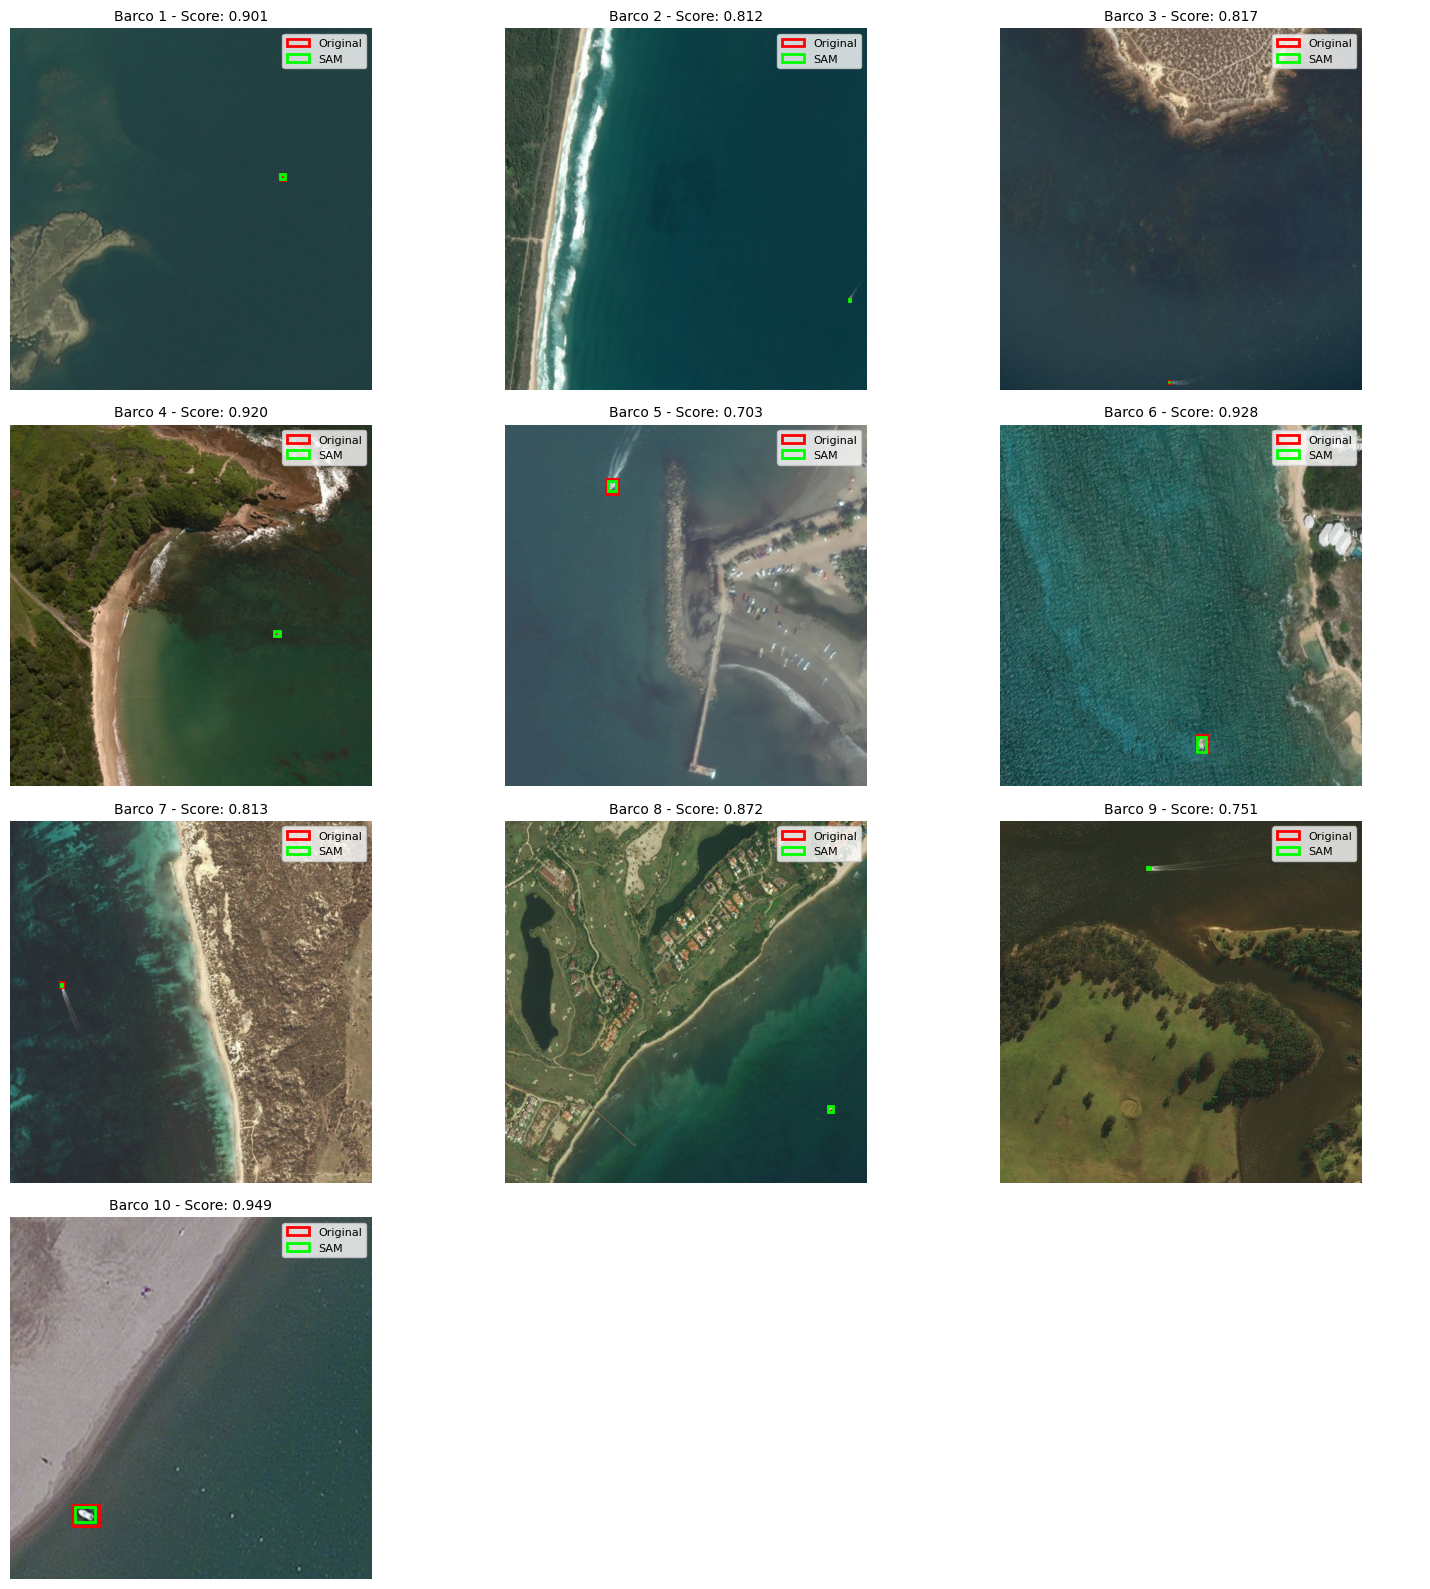

Visualización guardada en /content/resultados_sam.png


In [ ]:
if 'sam_results' in locals() and len(sam_results) > 0:
    import matplotlib.pyplot as plt
    from matplotlib.patches import Rectangle

    num_show = min(12, len(sam_results))
    fig, axes = plt.subplots(4, 3, figsize=(15, 16))
    axes = axes.flatten()

    for idx, result in enumerate(sam_results[:num_show]):
        img = cv2.imread(result['image_path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax = axes[idx]
        ax.imshow(img)

        ob = result['original_box']
        rect_orig = Rectangle((ob['xmin'], ob['ymin']),
                              ob['width'], ob['height'],
                              linewidth=2, edgecolor='red', facecolor='none', label='Original')
        ax.add_patch(rect_orig)

        sb = result['sam_box']
        rect_sam = Rectangle((sb['xmin'], sb['ymin']),
                             sb['width'], sb['height'],
                             linewidth=2, edgecolor='lime', facecolor='none', label='SAM')
        ax.add_patch(rect_sam)

        ax.set_title(f"Barco {idx+1} - Score: {result['sam_score']:.3f}", fontsize=10)
        ax.legend(loc='upper right', fontsize=8)
        ax.axis('off')

    for idx in range(num_show, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig('/content/resultados_sam.png', dpi=100, bbox_inches='tight')
    plt.show()
    print("Visualización guardada en /content/resultados_sam.png")
else:
    print("No hay resultados para visualizar")

Dataset con anotaciones SAM

In [ ]:
import shutil

if 'xml_dir' in locals() and xml_dir:
    sam_xml_dir = xml_dir + '_SAM'
    os.makedirs(sam_xml_dir, exist_ok=True)
    print(f"Carpeta creada: {sam_xml_dir}")

    print(f"\nCopiando {len(xml_files_all)} anotaciones originales")
    for xml_path in xml_files_all:
        filename = os.path.basename(xml_path)
        dest = os.path.join(sam_xml_dir, filename)
        if not os.path.exists(dest):
            shutil.copy(xml_path, dest)

    print(f"Anotaciones copiadas")

    if 'sam_results' in locals():
        print(f"\nActualizando anotaciones con SAM")
        updated = 0

        for result in sam_results:
            img_filename = os.path.basename(result['image_path'])

            for xml_path in glob.glob(os.path.join(sam_xml_dir, '*.xml')):
                tree = ET.parse(xml_path)
                root = tree.getroot()
                filename_elem = root.find('filename')

                if filename_elem is not None and filename_elem.text == img_filename:
                    for obj in root.findall('object'):
                        bndbox = obj.find('bndbox')
                        xmin = int(float(bndbox.find('xmin').text))
                        ymin = int(float(bndbox.find('ymin').text))
                        xmax = int(float(bndbox.find('xmax').text))
                        ymax = int(float(bndbox.find('ymax').text))

                        if (xmin == result['original_box']['xmin'] and
                            ymin == result['original_box']['ymin'] and
                            xmax == result['original_box']['xmax'] and
                            ymax == result['original_box']['ymax']):

                            bndbox.find('xmin').text = str(result['sam_box']['xmin'])
                            bndbox.find('ymin').text = str(result['sam_box']['ymin'])
                            bndbox.find('xmax').text = str(result['sam_box']['xmax'])
                            bndbox.find('ymax').text = str(result['sam_box']['ymax'])
                            updated += 1
                            break

                    tree.write(xml_path)
                    break

        print(f"{updated} bounding boxes actualizados")
        print(f"\nNuevo dataset guardado en: {sam_xml_dir}")
else:
    print("No se puede crear dataset SAM sin XML válidos")

Carpeta creada: /content/MASATI/MASATI-v2/coast_ship_labels_SAM

Copiando 1037 anotaciones originales
Anotaciones copiadas

Actualizando anotaciones con SAM
10 bounding boxes actualizados

Nuevo dataset guardado en: /content/MASATI/MASATI-v2/coast_ship_labels_SAM


Estadísticas

In [ ]:
if 'sam_results' in locals() and len(sam_results) > 0:
    import numpy as np

    print("ESTADÍSTICAS SAM")

    width_changes = []
    height_changes = []
    scores = []

    for result in sam_results:
        orig = result['original_box']
        sam = result['sam_box']
        width_changes.append(sam['width'] - orig['width'])
        height_changes.append(sam['height'] - orig['height'])
        scores.append(float(result['sam_score']))

    print(f"\nBARCOS PROCESADOS: {len(sam_results)}")
    print(f"\nCAMBIOS DE DIMENSIONES:")
    print(f"  Ancho promedio: {np.mean(width_changes):+.2f} px")
    print(f"  Altura promedio: {np.mean(height_changes):+.2f} px")
    print(f"\nSCORES SAM:")
    print(f"  Promedio: {np.mean(scores):.4f}")
    print(f"  Rango: [{min(scores):.4f}, {max(scores):.4f}]")
else:
    print("No hay resultados SAM para mostrar estadísticas")

ESTADÍSTICAS SAM

BARCOS PROCESADOS: 10

CAMBIOS DE DIMENSIONES:
  Ancho promedio: -1.90 px
  Altura promedio: -2.10 px

SCORES SAM:
  Promedio: 0.8466
  Rango: [0.7035, 0.9485]


Funciones para comparación

In [ ]:
def calculate_iou(box1, box2):
    x_left = max(box1['xmin'], box2['xmin'])
    y_top = max(box1['ymin'], box2['ymin'])
    x_right = min(box1['xmax'], box2['xmax'])
    y_bottom = min(box1['ymax'], box2['ymax'])

    if x_right < x_left or y_bottom < y_top:
        return 0.0

    intersection = (x_right - x_left) * (y_bottom - y_top)
    box1_area = (box1['xmax'] - box1['xmin']) * (box1['ymax'] - box1['ymin'])
    box2_area = (box2['xmax'] - box2['xmin']) * (box2['ymax'] - box2['ymin'])
    union = box1_area + box2_area - intersection

    return intersection / union if union > 0 else 0.0

def parse_xml(xml_path):
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        filename = root.find('filename').text
        boxes = []
        for obj in root.findall('object'):
            bndbox = obj.find('bndbox')
            box = {
                'xmin': int(float(bndbox.find('xmin').text)),
                'ymin': int(float(bndbox.find('ymin').text)),
                'xmax': int(float(bndbox.find('xmax').text)),
                'ymax': int(float(bndbox.find('ymax').text))
            }
            box['width'] = box['xmax'] - box['xmin']
            box['height'] = box['ymax'] - box['ymin']
            boxes.append(box)
        return {'filename': filename, 'boxes': boxes}
    except:
        return None

def find_image(filename, root):
    for r, dirs, files in os.walk(root):
        if filename in files:
            return os.path.join(r, filename)
    return None

print("Funciones cargadas")

Funciones cargadas


In [ ]:
if 'xml_dir' in locals() and 'sam_xml_dir' in locals():
    xml_files = glob.glob(os.path.join(xml_dir, '*.xml'))
    xml_files_sam = glob.glob(os.path.join(sam_xml_dir, '*.xml'))

    original_annots = {}
    for xml_path in xml_files:
        annot = parse_xml(xml_path)
        if annot:
            original_annots[annot['filename']] = annot

    sam_annots = {}
    for xml_path in xml_files_sam:
        annot = parse_xml(xml_path)
        if annot:
            sam_annots[annot['filename']] = annot

    common = set(original_annots.keys()) & set(sam_annots.keys())
    print(f"Originales: {len(original_annots)}")
    print(f"SAM: {len(sam_annots)}")
    print(f"Comunes: {len(common)}")
else:
    print("Error: Faltan carpetas XML")

Originales: 1037
SAM: 1037
Comunes: 1037


In [ ]:
iou_results = []

for img_file in common:
    orig = original_annots[img_file]
    sam = sam_annots[img_file]

    if len(orig['boxes']) != len(sam['boxes']):
        continue

    for orig_box, sam_box in zip(orig['boxes'], sam['boxes']):
        iou = calculate_iou(orig_box, sam_box)

        orig_area = orig_box['width'] * orig_box['height']
        sam_area = sam_box['width'] * sam_box['height']
        area_change = (sam_area - orig_area) / orig_area * 100 if orig_area > 0 else 0

        iou_results.append({
            'image': img_file,
            'iou': iou,
            'orig_box': orig_box,
            'sam_box': sam_box,
            'area_change': area_change
        })

print(f"Total comparaciones: {len(iou_results)}")
if len(iou_results) > 0:
    iou_scores = [r['iou'] for r in iou_results]
    print(f"IoU Promedio: {np.mean(iou_scores):.4f}")
    print(f"IoU Rango: [{min(iou_scores):.4f}, {max(iou_scores):.4f}]")

Total comparaciones: 1061
IoU Promedio: 0.9967
IoU Rango: [0.2500, 1.0000]


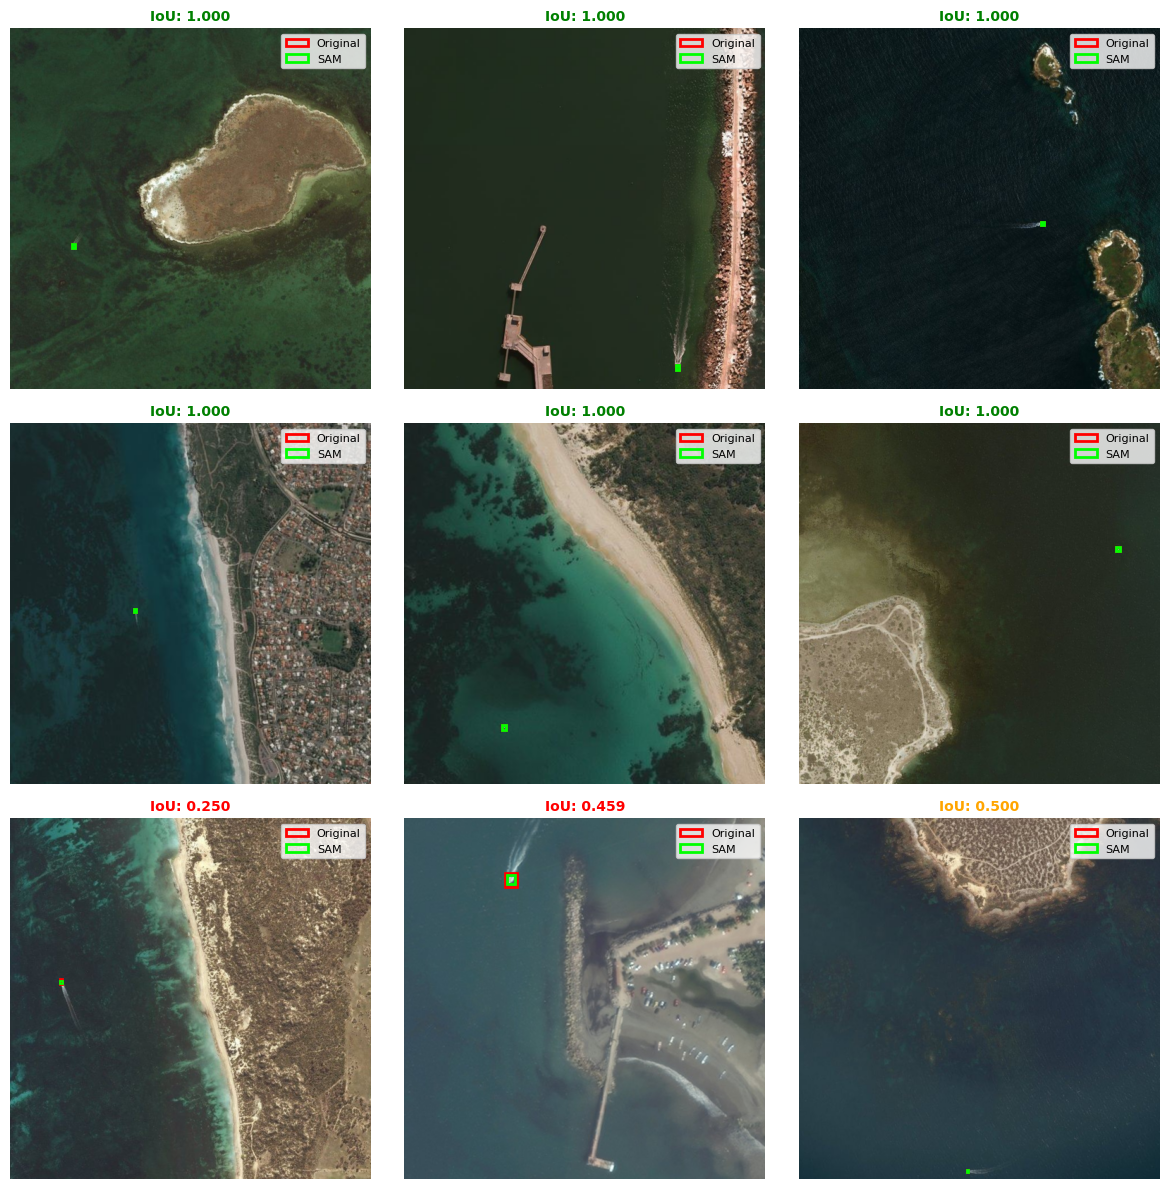

Visualizacion guardada


In [ ]:
if len(iou_results) > 9:
    results_sorted = sorted(iou_results, key=lambda x: x['iou'])
    good = results_sorted[-3:]
    bad = results_sorted[:3]
    mid = results_sorted[len(results_sorted)//2:len(results_sorted)//2 + 3]
    examples = good + mid + bad

    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.flatten()

    for idx, result in enumerate(examples[:9]):
        img_path = find_image(result['image'], masati_root)
        if not img_path or not os.path.exists(img_path):
            continue

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax = axes[idx]
        ax.imshow(img)

        ob = result['orig_box']
        rect1 = Rectangle((ob['xmin'], ob['ymin']),
                         ob['width'], ob['height'],
                         linewidth=2, edgecolor='red', facecolor='none', label='Original')
        ax.add_patch(rect1)

        sb = result['sam_box']
        rect2 = Rectangle((sb['xmin'], sb['ymin']),
                         sb['width'], sb['height'],
                         linewidth=2, edgecolor='lime', facecolor='none', label='SAM')
        ax.add_patch(rect2)

        iou_val = result['iou']
        color = 'green' if iou_val >= 0.8 else 'orange' if iou_val >= 0.5 else 'red'
        ax.set_title(f"IoU: {iou_val:.3f}", fontsize=10, color=color, weight='bold')
        ax.legend(loc='upper right', fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('/content/comparacion_iou.png', dpi=100, bbox_inches='tight')
    plt.show()
    print("Visualizacion guardada")

In [ ]:
if len(iou_results) > 0:
    iou_scores = [r['iou'] for r in iou_results]

    print("ESTADISTICAS IoU")

    print(f"\nMETRICAS:")
    print(f"  Total boxes: {len(iou_scores)}")
    print(f"  Promedio: {np.mean(iou_scores):.4f}")
    print(f"  Mediana: {np.median(iou_scores):.4f}")
    print(f"  Std Dev: {np.std(iou_scores):.4f}")
    print(f"  Rango: [{min(iou_scores):.4f}, {max(iou_scores):.4f}]")

    high_iou = sum(1 for s in iou_scores if s >= 0.8)
    med_iou = sum(1 for s in iou_scores if 0.5 <= s < 0.8)
    low_iou = sum(1 for s in iou_scores if s < 0.5)

    print(f"\nDISTRIBUCION:")
    print(f"  IoU >= 0.8: {high_iou} ({100*high_iou/len(iou_scores):.1f}%)")
    print(f"  0.5 <= IoU < 0.8: {med_iou} ({100*med_iou/len(iou_scores):.1f}%)")
    print(f"  IoU < 0.5: {low_iou} ({100*low_iou/len(iou_scores):.1f}%)")

ESTADISTICAS IoU

METRICAS:
  Total boxes: 1061
  Promedio: 0.9967
  Mediana: 1.0000
  Std Dev: 0.0391
  Rango: [0.2500, 1.0000]

DISTRIBUCION:
  IoU >= 0.8: 1054 (99.3%)
  0.5 <= IoU < 0.8: 5 (0.5%)
  IoU < 0.5: 2 (0.2%)


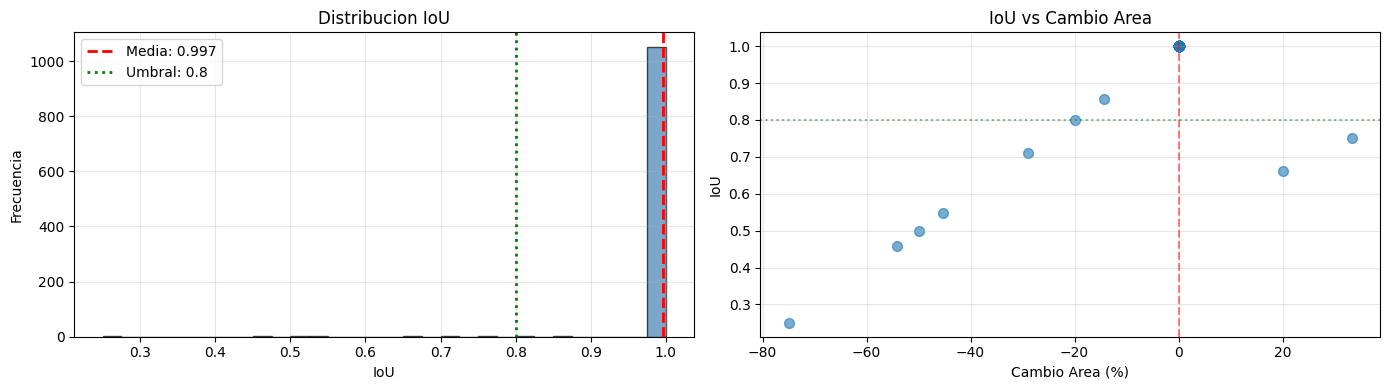

Graficos guardados


In [ ]:
if len(iou_results) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].hist(iou_scores, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].axvline(x=np.mean(iou_scores), color='red', linestyle='--', linewidth=2,
                    label=f'Media: {np.mean(iou_scores):.3f}')
    axes[0].axvline(x=0.8, color='green', linestyle=':', linewidth=2, label='Umbral: 0.8')
    axes[0].set_xlabel('IoU')
    axes[0].set_ylabel('Frecuencia')
    axes[0].set_title('Distribucion IoU')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    area_changes = [r['area_change'] for r in iou_results]
    axes[1].scatter(area_changes, iou_scores, alpha=0.6, s=50)
    axes[1].axhline(y=0.8, color='green', linestyle=':', alpha=0.5)
    axes[1].axvline(x=0, color='red', linestyle='--', alpha=0.5)
    axes[1].set_xlabel('Cambio Area (%)')
    axes[1].set_ylabel('IoU')
    axes[1].set_title('IoU vs Cambio Area')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/graficos_iou.png', dpi=100, bbox_inches='tight')
    plt.show()
    print("Graficos guardados")

In [ ]:
import pandas as pd
if len(iou_results) > 0:
    df = pd.DataFrame([
        {
            'Imagen': r['image'],
            'IoU': f"{r['iou']:.4f}",
            'Cambio_Area_Pct': f"{r['area_change']:.2f}"
        }
        for r in iou_results
    ])

    df.to_csv('/content/resultados_iou.csv', index=False)
    print("CSV exportado: /content/resultados_iou.csv")
    print("\nPrimeros registros:")
    print(df.head(10))

CSV exportado: /content/resultados_iou.csv

Primeros registros:
      Imagen     IoU Cambio_Area_Pct
0  x0801.png  1.0000            0.00
1  x0036.png  1.0000            0.00
2  x0115.png  1.0000            0.00
3  x0538.png  1.0000            0.00
4  x0293.png  1.0000            0.00
5  x0475.png  1.0000            0.00
6  x0348.png  1.0000            0.00
7  x0796.png  1.0000            0.00
8  x0133.png  1.0000            0.00
9  x0056.png  1.0000            0.00


### Conclusiones

Tras procesar las imágenes del dataset SAM y comparar las boxes resultantes con las manuales originales, tenemos las siguientes conclusiones clave:

1. **Precisión Sobresaliente (IoU Promedio de 99.67%):**
   - Coincidencia casi perfecta entre las anotaciones originales y las generadas de forma semiautomática por SAM demuestra que el modelo es altamente preciso para refinar y ajustar los límites del objeto de interés (en este caso, barcos en imágenes satelitales/aéreas).
   - Un **99.3% de las cajas** superan el umbral estricto de **IoU >= 0.8**, garantizando consistencia y calidad de nivel de producción.

2. **Correcciones Marginales y Robustez:**
   - Solo una porción insignificante de las cajas (**0.2%**) se ubicó por debajo de un IoU de 0.5. Esto suele corresponder a objetos extremadamente pequeños o ruidosos donde las cajas de anclaje iniciales de origen manual diferían en píxeles limítrofes.
   - La variación promedio en las dimensiones es mínima (reducción promedio de alrededor de 2 píxeles de ancho y alto), lo que indica que SAM compactó de forma limpia la máscara alrededor de los barcos reales eliminando espacio muerto redundante.

3. **Optimización del Pipeline:**
   - El flujo demuestra que utilizar SAM como asistente de anotación permite acelerar el etiquetado manual en nuevos conjuntos de datos masivos sin perder el estándar de calidad humano.